In [1]:
d! pip install kaggle

SyntaxError: ignored

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! mkdir ~/.kaggle

In [4]:
! cp kaggle.json ~/.kaggle/

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

In [6]:
! kaggle datasets download ashishjangra27/face-mask-12k-images-dataset

 97% 321M/330M [00:13<00:00, 46.7MB/s]
100% 330M/330M [00:13<00:00, 26.1MB/s]


In [7]:
! unzip face-mask-12k-images-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Face Mask Dataset/Train/WithoutMask/1855.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1856.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1857.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1858.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1859.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1860.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1861.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1862.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1863.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1864.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1865.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1866.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1867.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1868.png  
  inflating: Face Mask Dataset/Train/WithoutMask/1869.png  
  inflating: Face Mask Dataset/Train/WithoutMask/

In [8]:
import pandas as pd
import numpy as np
import cv2
import os
import glob
from scipy.spatial import distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, models
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPool2D
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import vgg19
from keras.applications.vgg19 import preprocess_input

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
img_rows, img_cols = 128, 128
model = vgg19.VGG19(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3))

for layer in model.layers:
    layer.trainable = False
    
model.summary()   

80150528/80134624 [==============================] - 1s 0us/step
Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                              

In [10]:
def layer_adder(bottom_model, num_classes):
    top_model=bottom_model.output
    top_model=GlobalAveragePooling2D()(top_model)
    top_model=Dense(100,activation='relu')(top_model)
    top_model=Dense(10,activation='relu')(top_model)
    top_model=Dense(num_classes,activation='softmax')(top_model)
    return top_model


In [11]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, Conv2D, MaxPooling2D, ZeroPadding2D
# from keras.layers.normalization import BatchNormalization
from keras.models import Model

num_classes = 2

FC_Head = layer_adder(model, num_classes)
model = Model(inputs = model.input, outputs = FC_Head)

print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [12]:
import pathlib
import tensorflow as tf

train_dir = '/content/Face Mask Dataset/Train'
test_dir = '/content/Face Mask Dataset/Test'
val_dir = '/content/Face Mask Dataset/Validation'

train_datagen = ImageDataGenerator(rescale=1.0/255, horizontal_flip=True, zoom_range=0.2,shear_range=0.2)
train_generator = train_datagen.flow_from_directory(directory=train_dir,target_size=(img_rows,img_cols),class_mode='categorical',batch_size=32)

val_datagen = ImageDataGenerator(rescale=1.0/255)
val_generator = train_datagen.flow_from_directory(directory=val_dir,target_size=(img_rows,img_cols),class_mode='categorical',batch_size=32)

test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = train_datagen.flow_from_directory(directory=val_dir,target_size=(img_rows,img_cols),class_mode='categorical',batch_size=32)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [13]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics ="accuracy")

epochs = 50

history = model.fit(train_generator, steps_per_epoch=len(train_generator)//32, epochs = epochs, validation_data=val_generator, validation_steps=len(val_generator)//32)

Epoch 1/50
9/9 [==============================] - 13s 259ms/step - loss: 0.6303 - accuracy: 0.6728
Epoch 2/50
9/9 [==============================] - 2s 174ms/step - loss: 0.4841 - accuracy: 0.8750
Epoch 3/50
9/9 [==============================] - 2s 167ms/step - loss: 0.3947 - accuracy: 0.8854
Epoch 4/50
9/9 [==============================] - 1s 170ms/step - loss: 0.3007 - accuracy: 0.9081
Epoch 5/50
9/9 [==============================] - 2s 171ms/step - loss: 0.2813 - accuracy: 0.8958
Epoch 6/50
9/9 [==============================] - 2s 169ms/step - loss: 0.2632 - accuracy: 0.8924
Epoch 7/50
9/9 [==============================] - 2s 172ms/step - loss: 0.2024 - accuracy: 0.9340
Epoch 8/50
9/9 [==============================] - 2s 176ms/step - loss: 0.2050 - accuracy: 0.9132
Epoch 9/50
9/9 [==============================] - 2s 168ms/step - loss: 0.2204 - accuracy: 0.9097
Epoch 10/50
9/9 [==============================] - 2s 169ms/step - loss: 0.1383 - accuracy: 0.9514
Epoch 11/50
9/9 [=

In [14]:
model.evaluate(test_generator)

25/25 [==============================] - 4s 166ms/step - loss: 0.0882 - accuracy: 0.9712


[0.08815234899520874, 0.9712499976158142]

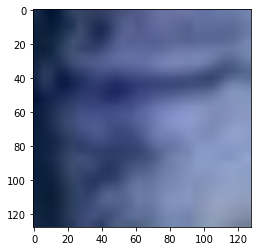

In [15]:
sample_mask_img = cv2.imread('/content/Face Mask Dataset/Test/WithoutMask/1175.png')
sample_mask_img = cv2.resize(sample_mask_img,(img_rows,img_cols))
plt.imshow(sample_mask_img)
sample_mask_img = np.reshape(sample_mask_img,[1,img_rows,img_cols,3])
sample_mask_img = sample_mask_img/255.0

In [16]:
mask_label = {0:'MASK',1:'NO MASK'}

mask_label[model.predict(sample_mask_img).argmax()]

'NO MASK'